<a href="https://colab.research.google.com/github/anishkr-sahu/revision_ml/blob/main/Revision_ml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# End-to-End Linear Regression Model Implementation

## 1. Setup and Data Loading

First, we'll import the necessary libraries and load the `Housing.csv` dataset into a pandas DataFrame.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv("/content/Housing.csv")

print("First 5 rows of the dataset:")
display(df.head())

First 5 rows of the dataset:


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


## 2. Initial Data Exploration

Let's understand the basic structure of our data, check for missing values, and review data types.

In [ ]:
print("Dataset Information:")
df.info()

print("\nMissing values per column:")
print(df.isnull().sum())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB

Missing values per column:
price               0
area                0
bedrooms            0
bathrooms           0
stories          

## 3. Feature Engineering

We need to convert categorical features into numerical formats that our model can understand. We'll use `LabelEncoder` for binary categorical features and `pd.get_dummies` for multi-category features like `furnishingstatus`.

In [ ]:
# Apply LabelEncoder to binary categorical columns
le = LabelEncoder()
binary_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']
for col in binary_cols:
    df[col] = le.fit_transform(df[col])

# Apply One-Hot Encoding to 'furnishingstatus'
df = pd.get_dummies(df, columns=['furnishingstatus'], drop_first=True)

print("First 5 rows after feature engineering:")
display(df.head())

First 5 rows after feature engineering:


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,False,False
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,False,False
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,True,False
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,False,False
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,False,False


## 4. Define Features (X) and Target (Y)

We separate the independent variables (features) from the dependent variable (target, which is 'price').

In [ ]:
X = df.drop('price', axis=1)  # All columns except 'price' are features
Y = df['price']  # 'price' is the target variable

print("Shape of X:", X.shape)
print("Shape of Y:", Y.shape)

Shape of X: (545, 13)
Shape of Y: (545,)


## 5. Split Data into Training and Testing Sets

We split the data to evaluate our model's performance on unseen data. A common split is 80% for training and 20% for testing.

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("Y_train shape:", Y_train.shape)
print("Y_test shape:", Y_test.shape)

X_train shape: (436, 13)
X_test shape: (109, 13)
Y_train shape: (436,)
Y_test shape: (109,)


## 6. Feature Scaling

Scaling features helps prevent features with larger values from dominating the learning process. We use `StandardScaler` to transform our features so they have a mean of 0 and a standard deviation of 1.

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("X_train_scaled (first 5 rows):\n", X_train_scaled[:5])

X_train_scaled (first 5 rows):
 [[ 0.38416819  0.05527092  1.53917323  2.58764353  0.40715525 -0.46677307
  -0.74642003 -0.23052136  1.50124327  0.36795665 -0.55262032 -0.870669
  -0.67690027]
 [ 0.9291807   0.05527092  1.53917323 -0.91249891  0.40715525 -0.46677307
   1.33972825 -0.23052136  1.50124327  2.70998729 -0.55262032  1.14854209
  -0.67690027]
 [-0.60775457 -1.28351359 -0.5579503  -0.91249891  0.40715525 -0.46677307
   1.33972825 -0.23052136  1.50124327  1.53897197 -0.55262032 -0.870669
  -0.67690027]
 [-1.15549214  0.05527092 -0.5579503   0.25421524  0.40715525 -0.46677307
   1.33972825 -0.23052136 -0.66611456 -0.80305867  1.80956067 -0.870669
   1.47732249]
 [-0.63773026  0.05527092 -0.5579503   0.25421524  0.40715525 -0.46677307
  -0.74642003 -0.23052136 -0.66611456 -0.80305867 -0.55262032 -0.870669
   1.47732249]]


## 7. Model Training

Now, we'll initialize and train our Linear Regression model using the scaled training data.

In [ ]:
model = LinearRegression()
model.fit(X_train_scaled, Y_train)

print("Linear Regression model trained successfully.")
print("Model coefficients:", model.coef_)
print("Model intercept:", model.intercept_)

Linear Regression model trained successfully.
Model coefficients: [ 519552.41633999   57349.55941862  521879.02774805  349251.43890557
  128498.62821472   88768.66768638  187067.80321388  149862.70299085
  365157.39385091  192005.95366749  266656.3519933   -62837.32186493
 -192015.91798221]
Model intercept: 4706527.385321101


## 8. Make Predictions

We'll use the trained model to make predictions on the scaled test data.

In [ ]:
predictions = model.predict(X_test_scaled)

print("First 20 predictions:")
print(predictions[:20])
print("\nActual values for the first 20 predictions:")
print(Y_test.head(20).values)

First 20 predictions:
[5164653.90033967 7224722.29802166 3109863.24240338 4612075.3272256
 3294646.25725956 3532275.09556558 5611774.56836474 6368145.98732718
 2722856.95689986 2629405.61585783 9617039.50315578 2798087.30447888
 3171096.76847064 3394639.09125529 3681088.65424276 5263187.74621486
 3035963.47612386 4786122.8004005  4349551.9200572  3572362.09930451]

Actual values for the first 20 predictions:
[ 4060000  6650000  3710000  6440000  2800000  4900000  5250000  4543000
  2450000  3353000 10150000  2660000  3360000  3360000  2275000  2660000
  2660000  7350000  2940000  2870000]


## 9. Model Evaluation

We'll evaluate the model's performance using common regression metrics: Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R-squared (R2).

In [ ]:
mse = mean_squared_error(Y_test, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(Y_test, predictions)

print(f"Mean Squared Error (MSE): {mse}")
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"R-squared (R2): {r2}")

Mean Squared Error (MSE): 1754318687330.668
Root Mean Squared Error (RMSE): 1324506.9600914402
R-squared (R2): 0.6529242642153176


## 10. Visualization of Predictions

Let's visualize the actual vs. predicted values to get a graphical understanding of the model's performance.

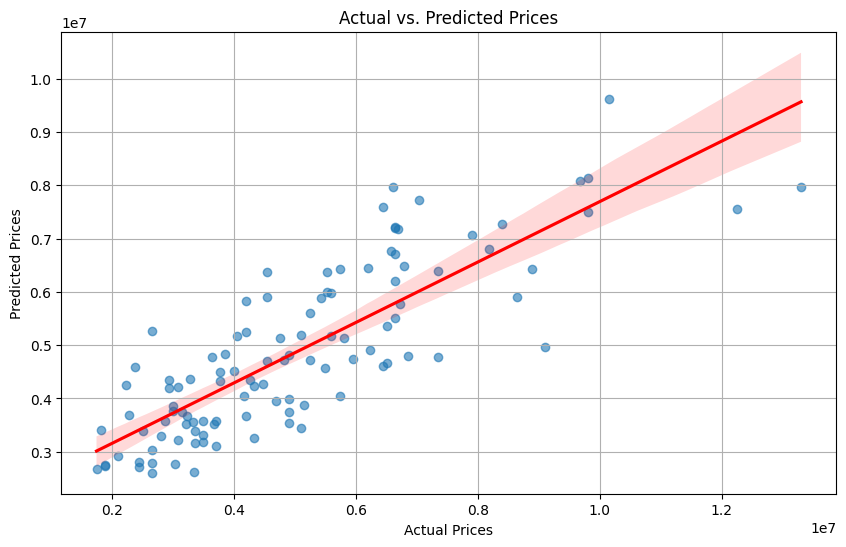

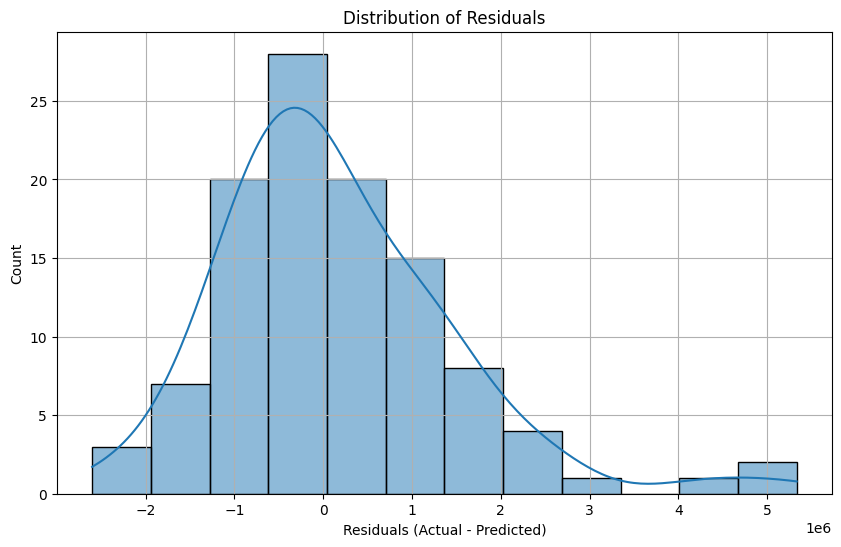

In [ ]:
plt.figure(figsize=(10, 6))
sns.regplot(x=Y_test, y=predictions, scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs. Predicted Prices")
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
sns.histplot(Y_test - predictions, kde=True)
plt.xlabel("Residuals (Actual - Predicted)")
plt.title("Distribution of Residuals")
plt.grid(True)
plt.show()

## 11. Improving Model Performance with Regularization (Ridge and Lasso)

Regularization techniques are used to prevent overfitting in linear regression models by adding a penalty to the loss function. This penalty discourages large coefficients, leading to simpler models that generalize better to unseen data.

### Ridge Regression (L2 Regularization)

Ridge regression adds an L2 penalty, which is the sum of the squared magnitudes of the coefficients, multiplied by a hyperparameter `alpha` (λ). The objective function becomes:

`Loss = MSE + alpha * Σ(coefficient^2)`

- It shrinks the coefficients towards zero but doesn't set them exactly to zero, meaning all features are retained.
- It is effective when there is multicollinearity among features.

### Lasso Regression (L1 Regularization)

Lasso regression adds an L1 penalty, which is the sum of the absolute magnitudes of the coefficients, multiplied by a hyperparameter `alpha` (λ). The objective function becomes:

`Loss = MSE + alpha * Σ|coefficient|`

- It shrinks coefficients towards zero and can set some coefficients exactly to zero, effectively performing feature selection.
- It is useful when you suspect that only a subset of features is truly important.

### Implementation of Ridge Regression

In [ ]:
from sklearn.linear_model import Ridge

# Initialize and train the Ridge Regression model
# The 'alpha' parameter controls the strength of the regularization.
# A higher alpha means more regularization.
ridge_model = Ridge(alpha=1.0) # You can tune this alpha value
ridge_model.fit(X_train_scaled, Y_train)

# Make predictions
ridge_predictions = ridge_model.predict(X_test_scaled)

# Evaluate the model
ridge_mse = mean_squared_error(Y_test, ridge_predictions)
ridge_rmse = np.sqrt(ridge_mse)
ridge_r2 = r2_score(Y_test, ridge_predictions)

print(f"Ridge Regression - Mean Squared Error (MSE): {ridge_mse}")
print(f"Ridge Regression - Root Mean Squared Error (RMSE): {ridge_rmse}")
print(f"Ridge Regression - R-squared (R2): {ridge_r2}")
print("Ridge Coefficients:", ridge_model.coef_)

Ridge Regression - Mean Squared Error (MSE): 1754839327446.8074
Ridge Regression - Root Mean Squared Error (RMSE): 1324703.4866138187
Ridge Regression - R-squared (R2): 0.6528212603810125
Ridge Coefficients: [ 518507.03823036   58203.88705657  520891.30346237  348503.40960966
  128787.60280692   89134.87763404  186543.41891169  149497.5857089
  364798.71516986  192163.57004515  266213.76642621  -62469.29415218
 -191654.57233891]


### Implementation of Lasso Regression

In [ ]:
from sklearn.linear_model import Lasso

# Initialize and train the Lasso Regression model
# Similar to Ridge, 'alpha' controls the regularization strength.
lasso_model = Lasso(alpha=1.0) # You can tune this alpha value
lasso_model.fit(X_train_scaled, Y_train)

# Make predictions
lasso_predictions = lasso_model.predict(X_test_scaled)

# Evaluate the model
lasso_mse = mean_squared_error(Y_test, lasso_predictions)
lasso_rmse = np.sqrt(lasso_mse)
lasso_r2 = r2_score(Y_test, lasso_predictions)

print(f"Lasso Regression - Mean Squared Error (MSE): {lasso_mse}")
print(f"Lasso Regression - Root Mean Squared Error (RMSE): {lasso_rmse}")
print(f"Lasso Regression - R-squared (R2): {lasso_r2}")
print("Lasso Coefficients:", lasso_model.coef_)

Lasso Regression - Mean Squared Error (MSE): 1754319994568.702
Lasso Regression - Root Mean Squared Error (RMSE): 1324507.4535723466
Lasso Regression - R-squared (R2): 0.6529240055903563
Lasso Coefficients: [ 519552.20160744   57349.25037985  521878.74841124  349250.97736781
  128498.26661015   88768.29364652  187067.24787181  149861.68200449
  365157.14248351  192005.64896691  266655.81326317  -62835.16692433
 -192014.12511764]


### Hyperparameter Tuning for Ridge and Lasso using GridSearchCV

To find the optimal `alpha` for both Ridge and Lasso regression, we'll use `GridSearchCV`. This method exhaustively searches over a specified parameter grid to find the best combination of parameters via cross-validation.

In [ ]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for alpha values
# We'll try a range of alpha values, often on a logarithmic scale
param_grid = {'alpha': [0.001, 0.01, 0.1, 1, 10, 100, 1000]}

print("--- Tuning Ridge Regression ---")

# Initialize Ridge Regression
ridge = Ridge()

# Initialize GridSearchCV
# scoring='r2' means we want to maximize R-squared
# cv=5 means 5-fold cross-validation
ridge_grid = GridSearchCV(ridge, param_grid, scoring='r2', cv=5, verbose=1, n_jobs=-1)

# Fit GridSearchCV to find the best alpha
ridge_grid.fit(X_train_scaled, Y_train)

print(f"Best alpha for Ridge: {ridge_grid.best_params_['alpha']}")
print(f"Best R-squared for Ridge (Cross-validation): {ridge_grid.best_score_}")

# Get the best Ridge model and evaluate on the test set
best_ridge_model = ridge_grid.best_estimator_
best_ridge_predictions = best_ridge_model.predict(X_test_scaled)
best_ridge_r2 = r2_score(Y_test, best_ridge_predictions)

print(f"Ridge Regression - R-squared on Test Set (with best alpha): {best_ridge_r2}")

--- Tuning Ridge Regression ---
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Best alpha for Ridge: 10
Best R-squared for Ridge (Cross-validation): 0.6484556256565075
Ridge Regression - R-squared on Test Set (with best alpha): 0.6517849312837285


In [ ]:
print("\n--- Tuning Lasso Regression ---")

# Initialize Lasso Regression
lasso = Lasso()

# Initialize GridSearchCV
lasso_grid = GridSearchCV(lasso, param_grid, scoring='r2', cv=5, verbose=1, n_jobs=-1)

# Fit GridSearchCV to find the best alpha
lasso_grid.fit(X_train_scaled, Y_train)

print(f"Best alpha for Lasso: {lasso_grid.best_params_['alpha']}")
print(f"Best R-squared for Lasso (Cross-validation): {lasso_grid.best_score_}")

# Get the best Lasso model and evaluate on the test set
best_lasso_model = lasso_grid.best_estimator_
best_lasso_predictions = best_lasso_model.predict(X_test_scaled)
best_lasso_r2 = r2_score(Y_test, best_lasso_predictions)

print(f"Lasso Regression - R-squared on Test Set (with best alpha): {best_lasso_r2}")


--- Tuning Lasso Regression ---
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Best alpha for Lasso: 1000
Best R-squared for Lasso (Cross-validation): 0.6470972655303938
Lasso Regression - R-squared on Test Set (with best alpha): 0.6526640249690197


### Analysis of Tuned Ridge and Lasso Models

After running `GridSearchCV`, we can compare the best R-squared scores obtained for Ridge and Lasso with their optimal `alpha` values, against our initial Linear Regression model.

*   **Best Alpha**: The `best_params_['alpha']` will show you the regularization strength that yielded the highest R-squared during cross-validation.
*   **Best R-squared (Cross-validation)**: This metric indicates the average R-squared across the cross-validation folds for the best `alpha`.
*   **R-squared on Test Set (with best alpha)**: This is the R-squared of the model with the optimal `alpha`, evaluated on the unseen test data. This is the most important metric for comparing performance.

We will now be able to see if the regularization techniques, with optimized hyperparameters, provide any significant improvement over the basic Linear Regression model. If the R-squared values are still very close, it might suggest that overfitting was not a major issue with this dataset, or that the linear model assumptions are being met reasonably well, and other strategies like feature engineering or exploring more complex models might be more beneficial.

In [ ]:
# linear regression model
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

In [ ]:
df = pd.read_csv("/content/Housing.csv")
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [ ]:
# feature engineering
df.isnull().sum()

,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


In [ ]:
#df = pd.get_dummies(df, drop_first=True)
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [ ]:
# feature engineering
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['mainroad'] = le.fit_transform(df['mainroad'])
df['guestroom'] = le.fit_transform(df['guestroom'])
df['basement'] = le.fit_transform(df['basement'])
df['hotwaterheating'] = le.fit_transform(df['hotwaterheating'])
df['airconditioning'] = le.fit_transform(df['airconditioning'])
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,yes,furnished
1,12250000,8960,4,4,4,1,0,0,0,1,3,no,furnished
2,12250000,9960,3,2,2,1,0,1,0,0,2,yes,semi-furnished
3,12215000,7500,4,2,2,1,0,1,0,1,3,yes,furnished
4,11410000,7420,4,1,2,1,1,1,0,1,2,no,furnished


In [ ]:
# independent variables (features column) and dependent variables(target column)
X = df[df.columns[1:11]]
Y = df['price']

In [ ]:
# split data into train and test
X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size=0.2, random_state=42)

In [ ]:
# feature scaling
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [ ]:
# call the model
model = LinearRegression()
model.fit(X_train, Y_train)

LinearRegression()

In [ ]:
pred = model.predict(X_test)
pred[:20]

array([5500225.42198385, 6547287.43683681, 3089285.27931947,
       4671133.17449009, 3168629.57511603, 3871846.5069246 ,
       5646818.3240794 , 5849269.53401795, 2885911.99512114,
       2306087.00458542, 9173519.91529335, 3062277.67251812,
       3280022.85694863, 3365576.29997798, 4128751.26057911,
       5397918.04308155, 2993260.8196387 , 5177208.59273068,
       4859040.77301954, 3588671.21640091])

In [ ]:
# measure the metrics
print("mse: ", mean_squared_error(Y_test, pred))
print("r2: ",r2_score(Y_test, pred))

mse:  1886508447723.2896
r2:  0.6267717420522665


In [ ]:
import numpy as np

rmse = np.sqrt(mean_squared_error(Y_test, pred))
print(f"RMSE: {rmse}")

RMSE: 1373502.2561769928


In [1]:
# logistic regression